Nama: Raka Muhammad Al Hafidz

NIM: 241344087

Kelas: 2C-TNK

In [3]:
import numpy as np
import matplotlib.pyplot as plt


Sebuah perangkat IoT merekam sinyal analog yang terkontaminasi oleh komponen frekuensi asing. Sinyal tersebut disampling dengan frekuensi fs = 4000 Hz selama 1 detik. Anda diberikan kode berikut di Python:

In [4]:
def generate_signal():
   np.random.seed(12)
   t = np.linspace(0, 1, 4000, endpoint=False)
   # Sinyal terdiri dari beberapa gelombang sinus + noise

   signal = 2.2 * np.sin(2 * np.pi * 5 * t) + \
   1.5 * np.sin(2 * np.pi * 20 * t) + \
   1.1 * np.sin(2 * np.pi * 80 * t) + \
   np.random.normal(0,1,len(t))

   return t, signal

1. Buat skrip python untuk menghitung FFT dari sinyal tersebut menggunakan scipy.ffft atau numpy.fft
2. Lakukan normalisasi magnitudo FFT dan hitung sumbu frekuensi fisik yang sesuai dalam satuan Hz
3. Plot spektrum magnitudo satu sisi (one sided spectrum). Tampilkan hanya frekuensi dari 0-200Hz
4. Tuliskan kode untuk mendeteksi secara otomatis 3 frekuensi dominan yang menyusun sinyal tersebut lalu cetak hasilnya ke konsol


In [5]:
fs = 4000  # Frekuensi sampling

#Sinyal yang digenerate dari fungsi
true_sinyal = generate_signal()

#Jumlah sampel dalam sinyal
n_signal = len(true_sinyal[1])


#Konversi fft dan frekuensi untuk sinyal yang digenerate:
signal_fft = np.fft.rfft(true_sinyal[1])
frequencies = np.fft.rfftfreq(n_signal, 1/fs)

#Normalisasi FFT dengan jumlah sampel
signal_fft_normalized = signal_fft / n_signal

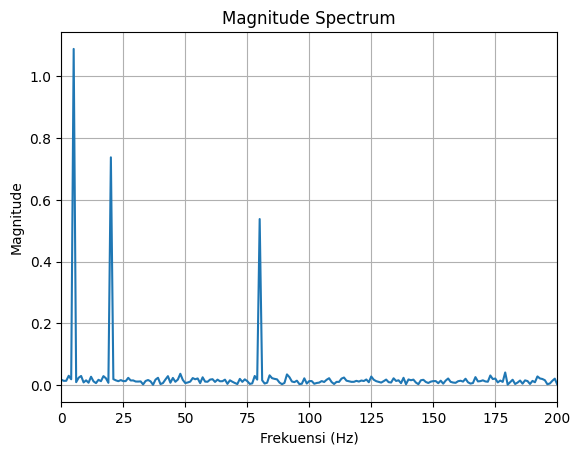

In [6]:
# Ploting:

plt.plot(frequencies, np.abs(signal_fft_normalized))
plt.title('Magnitude Spectrum')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 200)  # Batasi sumbu x untuk melihat frekuensi rendah
plt.grid()
plt.show()

In [7]:
#Pengambilan frekuensi dominan (lebih dari 0.5)
for i in frequencies:
    # Ambil magnitude untuk frekuensi dimana frekuensi sama dengan i
    magnitude = np.abs(signal_fft_normalized[np.where(frequencies == i)])
    #Jika lebih dari 0.5, maka frekuensi tersebut dianggap dominan
    if magnitude > 0.5:
        print(f"Frekuensi: {i} Hz, Magnitude: {magnitude}")


Frekuensi: 5.0 Hz, Magnitude: [1.08925224]
Frekuensi: 20.0 Hz, Magnitude: [0.73793532]
Frekuensi: 80.0 Hz, Magnitude: [0.53795396]


Soal 2: Implementasi Hard Filtering di Domain Frekuensi

Mengacu pada soal 1, anda diminta untuk melakukan hard filtering (filter Low-Pass ideal) langsung pada domain frekuensi. Tujuannya adalah untuk menghilangkan komponen frekuensi di atas 100Hz (Komponen 120Hz dan noise frekuensi tinggi harus dibuang sepenuhnya).

```python
# Gunakan fungsi generate_signal() dari soal 1 sebagai data input
```

Tugas:

1. Lakukan transformasi FFT pada sinyal asli untuk mendapatkan koefisien kompleksnya di domain frekuensi
2. Buatlah sebuah fungsi filter yang memotong (set nilai array koefisien menjadi 0) untuk semua komponen frekuensi yang memiliki nilai absolut fisik lebih besar dari 30Hz
3. Lakukan IFFT untuk mengembalikan sinyal ke domain waktu
4. Plot perbandingan sinyal asli dan sinyal hasil hard filtering (di domain frekuensi dan domain waktu) dalam satu figure menggunakan matplotlib

In [ ]:
#Mengambil sinyal asli dari generate_signal()
sinyal_asli = generate_signal()

#Jumlah sampel dalam sinyal asli
n_sinyal_asli = len(sinyal_asli[1])

# Konversi fft dan frekuensi untuk sinyal asli:
fft_sinyal_asli = np.fft.rfft(sinyal_asli[1])
frequencies_asli = np.fft.rfftfreq(n_sinyal_asli, 1/fs)
fft_sinyal_asli_normalized = fft_sinyal_asli / n_sinyal_asli

#Buat fungsi untuk cut frekuensi <30Hz
def filterate_signal(signal, freq, freq_cut):
    filtered_signal = signal.copy()
    filtered_signal[np.abs(freq) > freq_cut] = 0
    return filtered_signal


In [ ]:
#Sinyal yang sudah difilter:
filtered_signal = filterate_signal(fft_sinyal_asli_normalized, frequencies_asli, 30)

# Konversi kembali ke domain waktu:
reverse_fft = np.fft.irfft(filtered_signal) * n_sinyal_asli
# Durasi:
dur = len(reverse_fft) / fs
#Sumbu t:
t = np.linspace(0, dur, len(reverse_fft), endpoint=False)

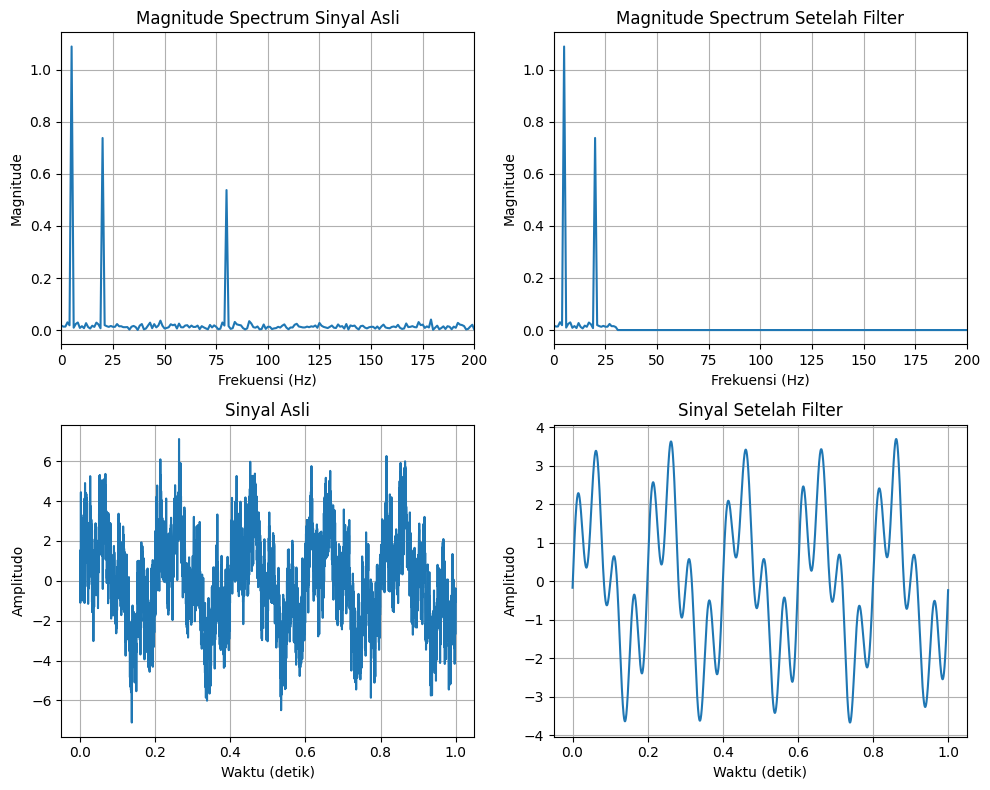

In [40]:
#Plot domain frekuensi dan domain waktu

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(frequencies_asli, np.abs(fft_sinyal_asli_normalized))
axes[0, 0].set_title('Magnitude Spectrum Sinyal Asli')
axes[0, 0].set_xlabel('Frekuensi (Hz)')
axes[0, 0].set_ylabel('Magnitude')
axes[0, 0].set_xlim(0, 200)
axes[0, 0].grid()

axes[0, 1].plot(frequencies_asli, np.abs(filtered_signal))
axes[0, 1].set_title('Magnitude Spectrum Setelah Filter')
axes[0, 1].set_xlabel('Frekuensi (Hz)')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].set_xlim(0, 200)
axes[0, 1].grid()

axes[1, 0].plot(sinyal_asli[0], sinyal_asli[1])
axes[1, 0].set_title('Sinyal Asli')
axes[1, 0].set_xlabel('Waktu (detik)')
axes[1, 0].set_ylabel('Amplitudo')
axes[1, 0].grid()

axes[1, 1].plot(t, reverse_fft)
axes[1, 1].set_title('Sinyal Setelah Filter')
axes[1, 1].set_xlabel('Waktu (detik)')
axes[1, 1].set_ylabel('Amplitudo')
axes[1, 1].grid()

plt.tight_layout()
plt.show()



# Soal 4: Efek Spectral Leakage dan Penerapan Windowing

Ketika melakukan FFT pada sinyal yang panjang datanya tidak mencakup kelipatan bulat dari periode sinyal, akan muncul fenomena kebocoran spektral (spectral leakage). Sinyal uji disampling pada fs = 1000Hz sepanjang 0.1 detik (N = 100 sampel)

In [1]:
import numpy as np

t = np.linspace(0, 0.1, 100, endpoint=False)
signal = np.sin(2 * np.pi * 65 * t) # Sinyal dengan frekuensi 65 Hz

Tugas:

1. Hitung dan plot spektrum magnitudo FFT dari sinyal asli (secara tidak langsung menggunakan Rectangular Window). Gunakan `np.fft.rfft()`
2. Kalikan siyal asli dengan Hann window (`scipy.signal.windows.hann`) sebelum melakukan proses FFT, lalu hitung spektrum magnitude nya.
3. Plot kedua spektrum tersebut dalam satu grafik dengan skala logaritmik desibel pada sumbu `Y: 20 * log10(magnitudo)`

In [ ]:
from scipy.signal.windows import hann

fs = 1000 # Frekuensi sampling
signal_fft = np.fft.rfft(signal)
frequencies = np.fft.rfftfreq(len(signal), 1/fs)  # Frekuensi sampling 1000 Hz
N = 100  # Jumlah sampel
